Deep Learning para visión de computadoras
Lab 1.4 Evaluación en clasificación de imágenes

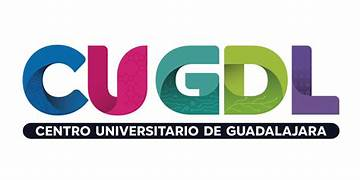

### Objetivo

Implementar y verificar, en código, los conceptos de la sesión teórica: métricas de clasificación (accuracy, precisión, recall, F1), una introducción práctica a IoU y AP, y el diagnóstico de overfitting a través de curvas de entrenamiento — conectando ese diagnóstico con las decisiones de arquitectura de 1.2 (campo receptivo, activaciones, batch normalization).


## Librerías

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score, f1_score,
    classification_report, precision_recall_curve, average_precision_score,
)

np.random.seed(1)
torch.manual_seed(1)

plt.rcParams["figure.figsize"] = (6.0, 4.0)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

print("NumPy:", np.__version__)
print("PyTorch:", torch.__version__)


NumPy: 2.4.4
PyTorch: 2.11.0+cpu


---
## 1. Matriz de confusión y métricas de clasificación en datos

In [2]:
def matriz_confusion_manual(y_real, y_pred):
    """
    Calcula (VP, FP, FN, VN) para un problema binario, sin usar librerías.

    Argumentos:
    y_real -- arreglo de 0/1 con las etiquetas verdaderas (1 = defectuosa)
    y_pred -- arreglo de 0/1 con las predicciones del modelo

    Regresa:
    (vp, fp, fn, vn)
    """
    y_real = np.asarray(y_real)
    y_pred = np.asarray(y_pred)

    vp = np.sum((y_pred == 1) & (y_real == 1))
    fp = np.sum((y_pred == 1) & (y_real == 0))
    fn = np.sum((y_pred == 0) & (y_real == 1))
    vn = np.sum((y_pred == 0) & (y_real == 0))
    return vp, fp, fn, vn


def metricas_desde_matriz(vp, fp, fn, vn):
    """Calcula accuracy, precisión, recall y F1 a partir de la matriz de confusión."""
    accuracy = (vp + vn) / (vp + vn + fp + fn)
    precision = vp / (vp + fp) if (vp + fp) > 0 else 0.0
    recall = vp / (vp + fn) if (vp + fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    return {"accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1}

np.random.seed(0)
y_real = np.array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0])  # 1 pieza defectuosa de 10 (desbalanceado)
y_pred_manual = np.array([1, 0, 0, 0, 1, 0, 0, 0, 0, 0])  # el modelo se equivoca en 1 caso (FP)

vp, fp, fn, vn = matriz_confusion_manual(y_real, y_pred_manual)
print(f"VP={vp}  FP={fp}  FN={fn}  VN={vn}")

metricas = metricas_desde_matriz(vp, fp, fn, vn)
for k, v in metricas.items():
    print(f"{k:10s}: {v:.3f}")


print("\nScikit-learn:")
print("accuracy :", accuracy_score(y_real, y_pred_manual))
print("precision:", precision_score(y_real, y_pred_manual, zero_division=0))
print("recall   :", recall_score(y_real, y_pred_manual, zero_division=0))
print("f1       :", f1_score(y_real, y_pred_manual, zero_division=0))


VP=1  FP=1  FN=0  VN=8
accuracy  : 0.900
precision : 0.500
recall    : 1.000
f1        : 0.667

Scikit-learn:
accuracy : 0.9
precision: 0.5
recall   : 1.0
f1       : 0.6666666666666666


### Accuracy con clases desbalanceadas


In [3]:
np.random.seed(3)
n = 100
n_defectuosas = 5

y_real_lote = np.zeros(n, dtype=int)
y_real_lote[:n_defectuosas] = 1
np.random.shuffle(y_real_lote)

# Modelo A
y_pred_A = np.zeros(n, dtype=int)
indices_defectuosas = np.where(y_real_lote == 1)[0]
y_pred_A[indices_defectuosas[0]] = 1  # detecta solo 1 de 5 por casualidad

# Modelo B
y_pred_B = np.zeros(n, dtype=int)
y_pred_B[indices_defectuosas[:4]] = 1
falsos_positivos_B = np.random.choice(np.where(y_real_lote == 0)[0], size=8, replace=False)
y_pred_B[falsos_positivos_B] = 1

resultados = {}
for nombre, y_pred in [("Modelo A", y_pred_A), ("Modelo B", y_pred_B)]:
    vp, fp, fn, vn = matriz_confusion_manual(y_real_lote, y_pred)
    m = metricas_desde_matriz(vp, fp, fn, vn)
    resultados[nombre] = m
    print(f"{nombre}")
    print(f"  VP={vp} FP={fp} FN={fn} VN={vn}")
    print(f"  accuracy={m['accuracy']:.3f}  precision={m['precision']:.3f}  recall={m['recall']:.3f}  f1={m['f1']:.3f}\n")


Modelo A
  VP=1 FP=0 FN=4 VN=95
  accuracy=0.960  precision=1.000  recall=0.200  f1=0.333

Modelo B
  VP=4 FP=8 FN=1 VN=87
  accuracy=0.910  precision=0.333  recall=0.800  f1=0.471



### 1.2 Ejercicio propuesto

Modifica `y_pred_B` arriba para que el modelo detecte las 5 piezas defectuosas (recall = 1.0) cometiendo el menor número posible de falsos positivos, y vuelve a correr la celda anterior. Observa cómo cambian precisión y F1.


---
## 2. Intersection over Union (IoU)

Implementamos IoU entre dos cajas delimitadoras, cada una representada como `(x_min, y_min, x_max, y_max)`, y la visualizamos como en la diapositiva 12.


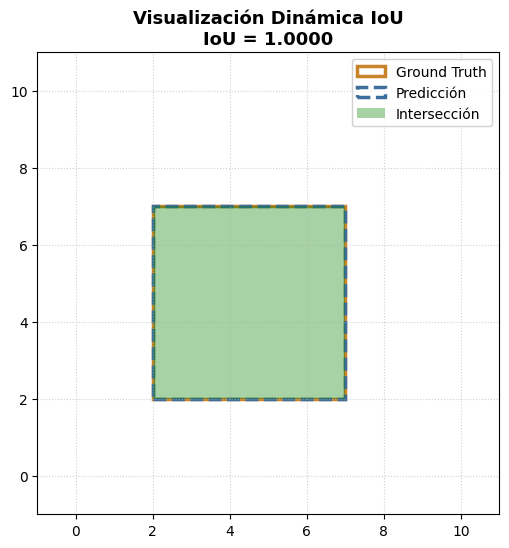

In [4]:
import time
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from IPython.display import clear_output

def calcular_iou(caja_a, caja_b):
    x_min_inter = max(caja_a[0], caja_b[0])
    y_min_inter = max(caja_a[1], caja_b[1])
    x_max_inter = min(caja_a[2], caja_b[2])
    y_max_inter = min(caja_a[3], caja_b[3])

    ancho_inter = max(0.0, x_max_inter - x_min_inter)
    alto_inter = max(0.0, y_max_inter - y_min_inter)
    area_interseccion = ancho_inter * alto_inter

    area_a = (caja_a[2] - caja_a[0]) * (caja_a[3] - caja_a[1])
    area_b = (caja_b[2] - caja_b[0]) * (caja_b[3] - caja_b[1])
    area_union = area_a + area_b - area_interseccion

    return (area_interseccion / area_union if area_union > 0 else 0.0), (x_min_inter, y_min_inter, ancho_inter, alto_inter)

def dibujar_cajas_animado(ground_truth, prediccion, iou, caja_inter):
    fig, ax = plt.subplots(figsize=(6, 6))
    gx0, gy0, gx1, gy1 = ground_truth
    px0, py0, px1, py1 = prediccion
    ix0, iy0, iw, ih = caja_inter

    # 1. Caja Ground Truth
    ax.add_patch(Rectangle((gx0, gy0), gx1 - gx0, gy1 - gy0,
                           fill=False, edgecolor="#C9832B", linewidth=2.5, label="Ground Truth"))

    # 2. Caja de Predicción
    ax.add_patch(Rectangle((px0, py0), px1 - px0, py1 - py0,
                           fill=False, edgecolor="#3E6D9C", linewidth=2.5, linestyle="--", label="Predicción"))

    # 3. Región de Intersección (sombreado)
    if iw > 0 and ih > 0:
        ax.add_patch(Rectangle((ix0, iy0), iw, ih,
                               facecolor="green", alpha=0.35, label="Intersección"))

    ax.set_xlim(-1, 11)
    ax.set_ylim(-1, 11)
    ax.set_aspect("equal")
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.legend(loc="upper right", framealpha=0.9)
    ax.set_title(f"Visualización Dinámica IoU\nIoU = {iou:.4f}", fontsize=13, fontweight="bold")

    plt.show()

ground_truth = (2.0, 2.0, 7.0, 7.0)

pasos_desplazamiento = np.linspace(8.0, 2.0, num=15)

for x_pos in pasos_desplazamiento:
    y_pos = x_pos
    prediccion = (x_pos, y_pos, x_pos + 5.0, y_pos + 5.0)

    iou, caja_inter = calcular_iou(ground_truth, prediccion)

    clear_output(wait=True)

    dibujar_cajas_animado(ground_truth, prediccion, iou, caja_inter)

    time.sleep(0.3)

### 2.1 Ejercicio propuesto

Modifica las coordenadas del siguiente codigo `prediccion` para lograr un IoU mayor a 0.8 sin que las dos cajas sean idénticas, y otra vez para lograr un IoU cercano a 0.5. Vuelve a correr la celda para confirmar visualmente.


IoU calculado: 0.316


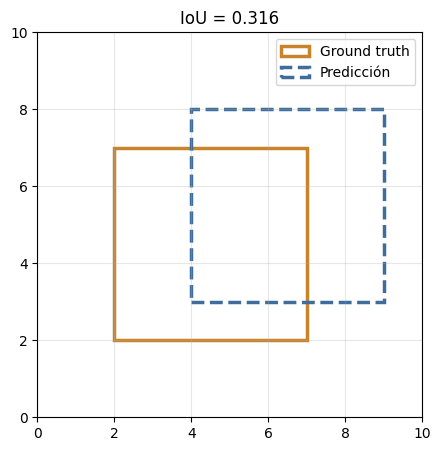

In [5]:
#Completar

def calcular_iou(caja_a, caja_b):
    """
    Calcula IoU entre dos cajas (x_min, y_min, x_max, y_max).

    Regresa:
    iou -- flotante en [0, 1]
    """
    x_min_inter = max(caja_a[0], caja_b[0])
    y_min_inter = max(caja_a[1], caja_b[1])
    x_max_inter = min(caja_a[2], caja_b[2])
    y_max_inter = min(caja_a[3], caja_b[3])

    ancho_inter = max(0.0, x_max_inter - x_min_inter)
    alto_inter = max(0.0, y_max_inter - y_min_inter)
    area_interseccion = ancho_inter * alto_inter

    area_a = (caja_a[2] - caja_a[0]) * (caja_a[3] - caja_a[1])
    area_b = (caja_b[2] - caja_b[0]) * (caja_b[3] - caja_b[1])
    area_union = area_a + area_b - area_interseccion

    return area_interseccion / area_union if area_union > 0 else 0.0


def dibujar_cajas(ground_truth, prediccion, iou):
    fig, ax = plt.subplots(figsize=(5, 5))
    gx0, gy0, gx1, gy1 = ground_truth
    px0, py0, px1, py1 = prediccion

    ax.add_patch(plt.Rectangle((gx0, gy0), gx1 - gx0, gy1 - gy0,
                                fill=False, edgecolor="#C9832B", linewidth=2.5, label="Ground truth"))
    ax.add_patch(plt.Rectangle((px0, py0), px1 - px0, py1 - py0,
                                fill=False, edgecolor="#3E6D9C", linewidth=2.5, linestyle="--", label="Predicción"))

    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)
    ax.set_aspect("equal")
    ax.legend(loc="upper right")
    ax.set_title(f"IoU = {iou:.3f}")
    plt.show()


ground_truth = (2, 2, 7, 7)
prediccion = (4, 3, 9, 8)

iou = calcular_iou(ground_truth, prediccion)
print(f"IoU calculado: {iou:.3f}")
dibujar_cajas(ground_truth, prediccion, iou)


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import seaborn as sns
from skimage import data

# -------------------------------------------------------------
# 1. Función Vectorizada de IoU
# -------------------------------------------------------------
def calcular_iou(box_a, box_b):
    # Formato: (x_min, y_min, x_max, y_max)
    x_min_inter = max(box_a[0], box_b[0])
    y_min_inter = max(box_a[1], box_b[1])
    x_max_inter = min(box_a[2], box_b[2])
    y_max_inter = min(box_a[3], box_b[3])

    w = max(0.0, x_max_inter - x_min_inter)
    h = max(0.0, y_max_inter - y_min_inter)
    inter = w * h

    area_a = (box_a[2] - box_a[0]) * (box_a[3] - box_a[1])
    area_b = (box_b[2] - box_b[0]) * (box_b[3] - box_b[1])
    union = area_a + area_b - inter

    return inter / union if union > 0 else 0.0

img = data.astronaut()

# Ground Truths reales (4 objetos: Rostro, Parche NASA, Emblema hombro, Casco)
ground_truths = [
    {"name": "Rostro",    "box": (160, 40,  270, 160)}, # GT 0
    {"name": "Parche_1",  "box": (120, 260, 210, 360)}, # GT 1
    {"name": "Emblema",   "box": (330, 160, 420, 270)}, # GT 2
    {"name": "Casco",     "box": (280, 320, 490, 500)}  # GT 3
]

# Predicciones simuladas de una CNN ordenadas por confianza descendente
predicciones = [
    {"box": (165, 45,  275, 165), "score": 0.96}, # 1. Alta confianza, IoU > 0.7 con Rostro       -> TP
    {"box": (115, 255, 205, 350), "score": 0.91}, # 2. Alta confianza, IoU > 0.8 con Parche_1     -> TP
    {"box": (170, 50,  260, 150), "score": 0.85}, # 3. Detección duplicada sobre Rostro (repetida) -> FP
    {"box": (30,  380, 120, 480), "score": 0.70}, # 4. Detección en fondo oscuro vacío            -> FP
    {"box": (310, 130, 390, 230), "score": 0.62}, # 5. IoU insuficiente (< 0.5) sobre Emblema      -> FP
    {"box": (335, 165, 415, 265), "score": 0.55}, # 6. Buen IoU con Emblema (reclamado tras fallo)-> TP
    {"box": (130, 280, 190, 340), "score": 0.38}  # 7. Duplicada sobre Parche_1 con bajo score    -> FP
]

# -------------------------------------------------------------
# 3. Matching por IoU (Threshold >= 0.5)
# -------------------------------------------------------------
iou_threshold = 0.5
gt_matched = [False] * len(ground_truths)

tps, fps, info_eval = [], [], []

for p_idx, pred in enumerate(predicciones):
    p_box = pred["box"]
    best_iou = 0.0
    best_gt_idx = -1

    for g_idx, gt in enumerate(ground_truths):
        iou = calcular_iou(p_box, gt["box"])
        if iou > best_iou:
            best_iou = iou
            best_gt_idx = g_idx

    # Si supera el umbral y el GT no ha sido asignado a una predicción previa más confiable
    if best_iou >= iou_threshold and not gt_matched[best_gt_idx]:
        tps.append(1)
        fps.append(0)
        gt_matched[best_gt_idx] = True
        info_eval.append((f"TP (IoU {best_iou:.2f})", "lime"))
    else:
        tps.append(0)
        fps.append(1)
        motivo = "Duplicada" if (best_iou >= iou_threshold and gt_matched[best_gt_idx]) else f"IoU={best_iou:.2f}"
        info_eval.append((f"FP ({motivo})", "red"))

tp_total = sum(tps)
fp_total = sum(fps)
fn_total = gt_matched.count(False)

# -------------------------------------------------------------
# 4. Cálculo de Métricas y Average Precision (AP)
# -------------------------------------------------------------
tp_acum = np.cumsum(tps)
fp_acum = np.cumsum(fps)

precisiones = tp_acum / (tp_acum + fp_acum)
recalls = tp_acum / len(ground_truths)

mrec = np.concatenate(([0.0], recalls, [recalls[-1]]))
mpre = np.concatenate(([1.0], precisiones, [0.0]))

for i in range(len(mpre) - 2, -1, -1):
    mpre[i] = max(mpre[i], mpre[i + 1])

indices = np.where(mrec[1:] != mrec[:-1])[0]
ap = np.sum((mrec[indices + 1] - mrec[indices]) * mpre[indices + 1])

fig = plt.figure(figsize=(18, 5.5))

ax1 = fig.add_subplot(1, 3, 1)
ax1.imshow(img)

for g_idx, gt in enumerate(ground_truths):
    b = gt["box"]
    ax1.add_patch(Rectangle((b[0], b[1]), b[2]-b[0], b[3]-b[1],
                            fill=False, edgecolor="#00E5FF", linewidth=2.2))
    estado = "Detectado" if gt_matched[g_idx] else "FN (Omitido)"
    ax1.text(b[0], b[1] - 8, f"GT: {gt['name']} [{estado}]", color="#00E5FF",
             fontsize=8, fontweight="bold", backgroundcolor="black")

for p_idx, pred in enumerate(predicciones):
    b = pred["box"]
    tag, col = info_eval[p_idx]
    ax1.add_patch(Rectangle((b[0], b[1]), b[2]-b[0], b[3]-b[1],
                            fill=False, edgecolor=col, linestyle="--", linewidth=1.8))
    ax1.text(b[0], b[3] + 14, f"{tag} | {pred['score']:.2f}", color=col,
             fontsize=7.5, fontweight="bold", backgroundcolor="black")

ax1.set_title("Detecciones sobre Imagen Real (512x512)\nCyan=GT | Verde=TP | Rojo=FP", fontsize=11)
ax1.axis("off")

ax2 = fig.add_subplot(1, 3, 2)
cm = np.array([
    [tp_total, fp_total],
    [fn_total, 0]
])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax2, annot_kws={"size": 14})
ax2.set_xticklabels(["Caja Válida (TP)", "Falsa Alarma (FP)"], fontsize=10)
ax2.set_yticklabels(["Objeto Real Presente", "Fondo / No Anotado"], fontsize=10)
ax2.set_title(f"Matriz de Confusión\n(GTs totales: {len(ground_truths)})", fontsize=11)
ax2.set_ylabel("Ground Truth")

# Panel 3: Curva Precision-Recall
ax3 = fig.add_subplot(1, 3, 3)
ax3.step(mrec, mpre, where="post", color="#E67E22", linewidth=2, label="Envolvente interpolada")
ax3.plot(recalls, precisiones, marker="o", markersize=6, linestyle="none", color="#8E44AD", label="Pasos evaluados")
ax3.fill_between(mrec, mpre, step="post", alpha=0.15, color="#E67E22")
ax3.set_xlim([0.0, 1.05])
ax3.set_ylim([0.0, 1.05])
ax3.set_xlabel("Recall (Sensibilidad)", fontsize=10)
ax3.set_ylabel("Precision (Precisión)", fontsize=10)
ax3.set_title(f"Curva Precision-Recall | AP = {ap:.3f}", fontsize=11)
ax3.grid(True, linestyle=":", alpha=0.6)
ax3.legend(loc="lower left")

plt.tight_layout()
plt.show()


ModuleNotFoundError: No module named 'seaborn'

# COMPLETAR CON EL ASTRONAUTA

Define numericamente y escribe un breve comentario ejemplificando

Total Ground Truths anotados=   color + etiquetas

Total Predicciones evaluadas =

Verdaderos Positivos (TP)=  Explicar casos del austronauta

Falsos Positivos     (FP)=  Explicar casos del astronauta

Falsos Negativos     (FN)=  Explicar casos del astronauta

Precisión Global=

Recall Global=

Average Precision (AP)=



## 3. Curva Precisión–Recall y Average Precision (AP)

Simulamos un pequeño detector que produjo 12 predicciones ya ordenadas de mayor a menor confianza, cada una marcada como acierto (1) o error (0) según si su IoU superó el umbral

Predicción  |  Acierto  |  Precisión acum.  |  Recall acum.
           1  |        1  |             1.000  |         0.167
           2  |        1  |             1.000  |         0.333
           3  |        0  |             0.667  |         0.333
           4  |        1  |             0.750  |         0.500
           5  |        1  |             0.800  |         0.667
           6  |        0  |             0.667  |         0.667
           7  |        0  |             0.571  |         0.667
           8  |        1  |             0.625  |         0.833
           9  |        0  |             0.556  |         0.833
          10  |        1  |             0.600  |         1.000
          11  |        0  |             0.545  |         1.000
          12  |        0  |             0.500  |         1.000

Average Precision (AP) ≈ 0.638


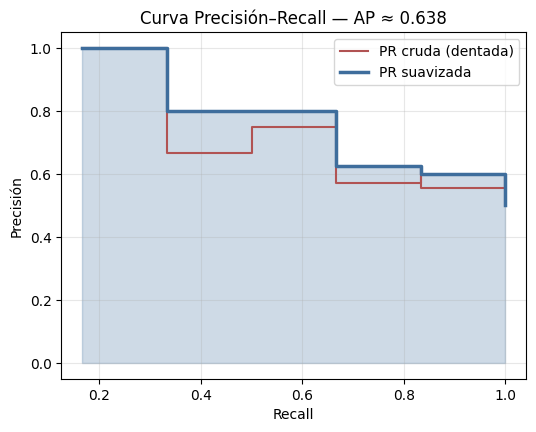

In [ ]:
aciertos_ordenados = np.array([1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0])
total_positivos_reales = 6

vp_acumulado = np.cumsum(aciertos_ordenados)
n_predicciones = np.arange(1, len(aciertos_ordenados) + 1)

precision_acumulada = vp_acumulado / n_predicciones
recall_acumulado = vp_acumulado / total_positivos_reales

print("Predicción  |  Acierto  |  Precisión acum.  |  Recall acum.")
for i in range(len(aciertos_ordenados)):
    print(f"{i+1:12d}  |  {aciertos_ordenados[i]:7d}  |  {precision_acumulada[i]:16.3f}  |  {recall_acumulado[i]:12.3f}")

precision_suavizada = np.maximum.accumulate(precision_acumulada[::-1])[::-1]

orden = np.argsort(recall_acumulado)
trapecio = getattr(np, "trapezoid", None) or np.trapz
ap = trapecio(precision_suavizada[orden], recall_acumulado[orden])
print(f"\nAverage Precision (AP) ≈ {ap:.3f}")

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.step(recall_acumulado, precision_acumulada, where="post", color="#B15353", label="PR cruda (dentada)")
ax.step(recall_acumulado[orden], precision_suavizada[orden], where="post", color="#3E6D9C", linewidth=2.5, label="PR suavizada")
ax.fill_between(recall_acumulado[orden], precision_suavizada[orden], step="post", alpha=0.25, color="#3E6D9C")
ax.set_xlabel("Recall")
ax.set_ylabel("Precisión")
ax.set_title(f"Curva Precisión–Recall — AP ≈ {ap:.3f}")
ax.legend()
plt.show()


---
## 4. Overfitting CNN pequeña



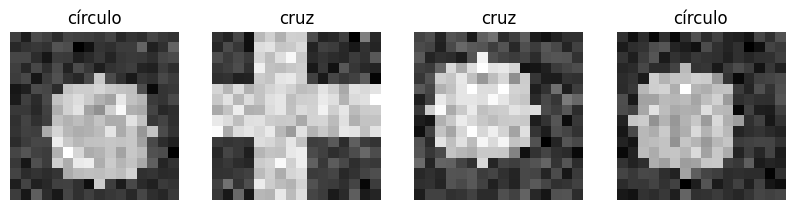

In [ ]:
def generar_dataset(n_ejemplos, tam=16, ruido=0.15, semilla=None):
    """
    Genera imágenes sintéticas de dos clases: círculo (0) y cruz (1),
    en posición aleatoria, con ruido gaussiano.
    """
    rng = np.random.default_rng(semilla)
    X = np.zeros((n_ejemplos, 1, tam, tam), dtype=np.float32)
    y = np.zeros(n_ejemplos, dtype=np.int64)

    centro = tam // 2
    yy, xx = np.mgrid[0:tam, 0:tam]

    for i in range(n_ejemplos):
        clase = rng.integers(0, 2)
        y[i] = clase
        cx = centro + rng.integers(-2, 3)
        cy = centro + rng.integers(-2, 3)

        if clase == 0:  # círculo
            radio = tam // 3
            mascara = (xx - cx) ** 2 + (yy - cy) ** 2 <= radio ** 2
        else:  # cruz
            grosor = 2
            mascara = (np.abs(xx - cx) <= grosor) | (np.abs(yy - cy) <= grosor)

        imagen = mascara.astype(np.float32)
        imagen += rng.normal(0, ruido, size=imagen.shape)
        X[i, 0] = imagen

    return torch.tensor(X), torch.tensor(y)


torch.manual_seed(0)
X_train, y_train = generar_dataset(40, semilla=1)   # set de ENTRENAMIENTO pequeño a propósito
X_val, y_val = generar_dataset(200, semilla=2)       # set de validación más grande, sin corromper


def corromper_etiquetas(y, fraccion, semilla=0):

    rng = np.random.default_rng(semilla)
    y_corrupto = y.clone()
    n_corromper = int(len(y) * fraccion)
    indices = rng.choice(len(y), size=n_corromper, replace=False)
    y_corrupto[indices] = 1 - y_corrupto[indices]
    return y_corrupto


y_train = corromper_etiquetas(y_train, fraccion=0.25, semilla=7)

fig, axs = plt.subplots(1, 4, figsize=(10, 3))
for i, ax in enumerate(axs):
    ax.imshow(X_train[i, 0], cmap="gray")
    ax.set_title("círculo" if y_train[i] == 0 else "cruz")
    ax.axis("off")
plt.show()


In [ ]:
#COMPLETAR
#dimensiones de entrada
#print("Forma de X_train:",  , " X_val:",  )
#print("Forma de y_train:",  , " y_val:",  )
print("Nota: algunas etiquetas del set de entrenamiento son intencionalmente incorrectas;")
print("el set de validación permanece limpio.")

Nota: algunas etiquetas del set de entrenamiento son intencionalmente incorrectas;
el set de validación permanece limpio.


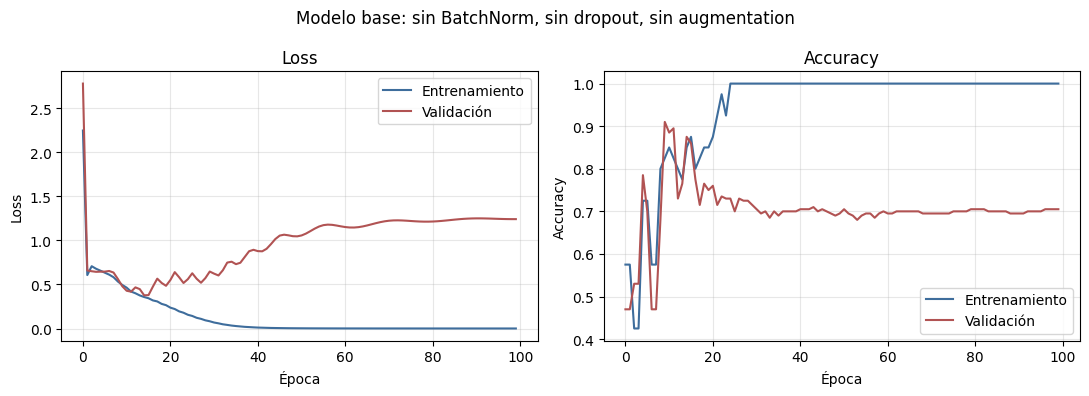

In [ ]:
class CNNPequena(nn.Module):
    """Conv -> (BN opcional) -> ReLU -> Pool, repetido, + FC final."""
    def __init__(self, usar_bn=False, usar_dropout=False):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32) if usar_bn else nn.Identity()
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64) if usar_bn else nn.Identity()
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.5) if usar_dropout else nn.Identity()
        self.fc = nn.Linear(64 * 4 * 4, 2)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        x = self.pool(self.relu(self.bn2(self.conv2(x))))
        x = self.dropout(x.flatten(1))
        return self.fc(x)


def aumentar_datos(X):
    """Data augmentation simple: flips aleatorios + ruido adicional."""
    X_aug = X.clone()
    if torch.rand(1).item() > 0.5:
        X_aug = torch.flip(X_aug, dims=[3])
    if torch.rand(1).item() > 0.5:
        X_aug = torch.flip(X_aug, dims=[2])
    X_aug = X_aug + torch.randn_like(X_aug) * 0.05
    return X_aug


def entrenar(modelo, n_epocas=100, lr=0.01, usar_augmentation=False):
    opt = torch.optim.Adam(modelo.parameters(), lr=lr)
    perdida_fn = nn.CrossEntropyLoss()
    hist = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoca in range(n_epocas):
        modelo.train()
        x_batch = aumentar_datos(X_train) if usar_augmentation else X_train
        opt.zero_grad()
        salida = modelo(x_batch)
        perdida = perdida_fn(salida, y_train)
        perdida.backward()
        opt.step()

        modelo.eval()
        with torch.no_grad():
            salida_train = modelo(X_train)
            perdida_train = perdida_fn(salida_train, y_train).item()
            acc_train = (salida_train.argmax(1) == y_train).float().mean().item()

            salida_val = modelo(X_val)
            perdida_val = perdida_fn(salida_val, y_val).item()
            acc_val = (salida_val.argmax(1) == y_val).float().mean().item()

        hist["train_loss"].append(perdida_train)
        hist["val_loss"].append(perdida_val)
        hist["train_acc"].append(acc_train)
        hist["val_acc"].append(acc_val)

    return hist


def graficar_curvas(hist, titulo):
    fig, axs = plt.subplots(1, 2, figsize=(11, 4))
    axs[0].plot(hist["train_loss"], label="Entrenamiento", color="#3E6D9C")
    axs[0].plot(hist["val_loss"], label="Validación", color="#B15353")
    axs[0].set_xlabel("Época"); axs[0].set_ylabel("Loss"); axs[0].legend()
    axs[0].set_title("Loss")

    axs[1].plot(hist["train_acc"], label="Entrenamiento", color="#3E6D9C")
    axs[1].plot(hist["val_acc"], label="Validación", color="#B15353")
    axs[1].set_xlabel("Época"); axs[1].set_ylabel("Accuracy"); axs[1].legend()
    axs[1].set_title("Accuracy")

    plt.suptitle(titulo)
    plt.tight_layout()
    plt.show()


torch.manual_seed(0)
modelo_base = CNNPequena(usar_bn=False, usar_dropout=False)
hist_base = entrenar(modelo_base, n_epocas=100)
graficar_curvas(hist_base, "Modelo base: sin BatchNorm, sin dropout, sin augmentation")




In [ ]:
#COMPLETA
#print(f"Accuracy final train: {     }   val: {    } ")

### 4.1 Diagnóstico

Mira las curvas que acabas de generar y responde,

¿el modelo base muestra un patrón esperado, de overfitting, de underfitting o inestable, según el checklist de clase? Justifica con lo que observas en el gap train/val.


---
## 5. Mitigar el overfitting: BatchNorm, dropout y data augmentation


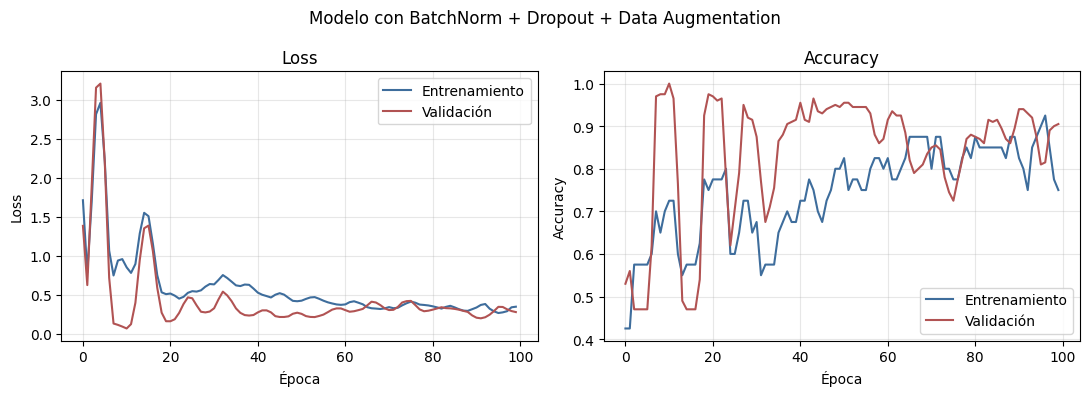

In [ ]:
torch.manual_seed(42)
modelo_mitigado = CNNPequena(usar_bn=True, usar_dropout=True)
hist_mitigado = entrenar(modelo_mitigado, n_epocas=100, usar_augmentation=True)
graficar_curvas(hist_mitigado, "Modelo con BatchNorm + Dropout + Data Augmentation")

In [ ]:
#COMPLETA
#print(f"Accuracy final train: {     }   val: {    } ")

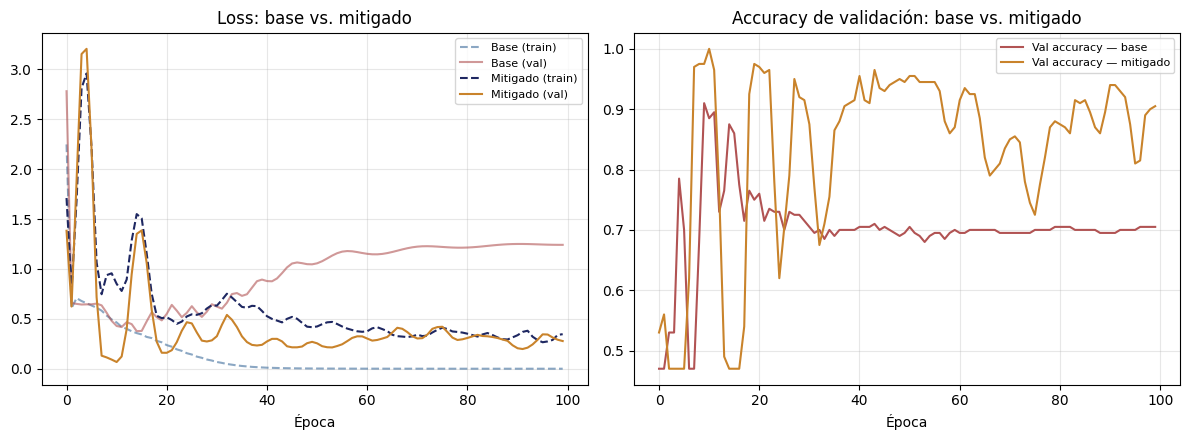

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4.5))
axs[0].plot(hist_base["train_loss"], "--", color="#3E6D9C", alpha=0.6, label="Base (train)")
axs[0].plot(hist_base["val_loss"], color="#B15353", alpha=0.6, label="Base (val)")
axs[0].plot(hist_mitigado["train_loss"], "--", color="#1E2761", label="Mitigado (train)")
axs[0].plot(hist_mitigado["val_loss"], color="#C9832B", label="Mitigado (val)")
axs[0].set_title("Loss: base vs. mitigado")
axs[0].set_xlabel("Época"); axs[0].legend(fontsize=8)

axs[1].plot(hist_base["val_acc"], color="#B15353", label="Val accuracy — base")
axs[1].plot(hist_mitigado["val_acc"], color="#C9832B", label="Val accuracy — mitigado")
axs[1].set_title("Accuracy de validación: base vs. mitigado")
axs[1].set_xlabel("Época"); axs[1].legend(fontsize=8)
plt.tight_layout()
plt.show()


In [ ]:
#COMPLETAR
#print(f"Gap train-val accuracy — modelo base    : {         }")
#print(f"Gap train-val accuracy — modelo mitigado: {         }")

Con datos sintéticos y pocas épocas, los resultados exactos varían entre ejecuciones lo relevante es comparar la *forma* de las curvas y el tamaño del gap final, no un número aislado. Un gap más pequeño en el modelo mitigado respalda la idea de que BatchNorm, dropout y augmentation actúan como reguladores frente al mismo modelo base.


---
## 6. Reporte final de métricas

Cerramos el círculo: calculamos accuracy, precisión, recall y F1 sobre el set de validación del modelo mitigado, usando `classification_report` de scikit-learn — el mismo tipo de reporte que se espera en la evidencia de laboratorio de la Unidad 1.


              precision    recall  f1-score   support

     círculo       0.87      0.97      0.92       106
        cruz       0.96      0.83      0.89        94

    accuracy                           0.91       200
   macro avg       0.91      0.90      0.90       200
weighted avg       0.91      0.91      0.90       200



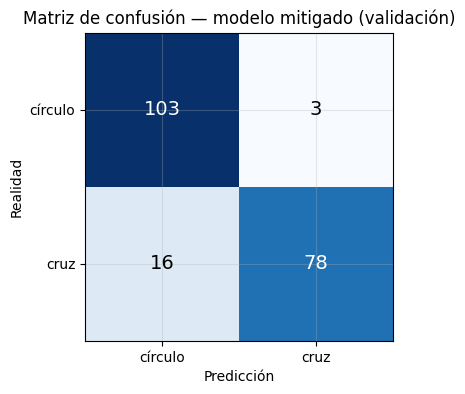

In [ ]:
modelo_mitigado.eval()
with torch.no_grad():
    pred_val = modelo_mitigado(X_val).argmax(1).numpy()

y_val_np = y_val.numpy()

print(classification_report(y_val_np, pred_val, target_names=["círculo", "cruz"], zero_division=0))

matriz = confusion_matrix(y_val_np, pred_val)
fig, ax = plt.subplots(figsize=(4, 4))
im = ax.imshow(matriz, cmap="Blues")
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(matriz[i, j]), ha="center", va="center",
                color="white" if matriz[i, j] > matriz.max() / 2 else "black", fontsize=14)
ax.set_xticks([0, 1]); ax.set_xticklabels(["círculo", "cruz"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["círculo", "cruz"])
ax.set_xlabel("Predicción"); ax.set_ylabel("Realidad")
ax.set_title("Matriz de confusión — modelo mitigado (validación)")
plt.show()


### Recursos complementarios citados en la sesión

- Katanforoosh, K., & Ng, A. *Stanford CS230: Deep Learning* — Section 8 (Week 8), "Advanced Evaluation Metrics". [cs230.stanford.edu/section/8](https://cs230.stanford.edu/section/8)
- Ultralytics. *Consejos y buenas prácticas para entrenar modelos*. [docs.ultralytics.com/es/guides/model-training-tips](https://docs.ultralytics.com/es/guides/model-training-tips)
- Ultralytics. *Métricas de rendimiento de YOLO* (referencia para la Unidad 2). [docs.ultralytics.com/es/guides/yolo-performance-metrics](https://docs.ultralytics.com/es/guides/yolo-performance-metrics)
- Ayyadevara, K., & Reddy, Y. (2024). *Modern Computer Vision with PyTorch*. Packt Publishing.
